In [ ]:
import os
import shutil

root_dir = "./Wound_dataset"
merged_train_dir = "./merged/train"

target_classes = [
    "Abrasions", "Bruises", "Burns", "Cut", "Diabetic Wounds",
    "Laceration", "Normal", "Pressure Wounds", "Surgical Wounds", "Venous Wounds"
]

aliases = {
    "Laceration": ["Laceration", "Laseration"]
}

os.makedirs(merged_train_dir, exist_ok=True)
for cls in target_classes:
    os.makedirs(os.path.join(merged_train_dir, cls), exist_ok=True)

def src_names_for(cls):
    return aliases.get(cls, [cls])


for entry in os.listdir(root_dir):
    entry_path = os.path.join(root_dir, entry)
    if not os.path.isdir(entry_path):
        continue

    matched = False
    for cls in target_classes:
        for src_name in src_names_for(cls):
            if entry == src_name:
                dst = os.path.join(merged_train_dir, cls)
                for img in os.listdir(entry_path):
                    if img.lower().endswith((".jpg", ".jpeg", ".png", ".bmp")):
                        shutil.copy(os.path.join(entry_path, img), dst)
                matched = True
                break
        if matched:
            break

    if not matched:
        for cls in target_classes:
            for src_name in src_names_for(cls):
                cls_src = os.path.join(entry_path, src_name)
                if os.path.isdir(cls_src):
                    dst = os.path.join(merged_train_dir, cls)
                    for img in os.listdir(cls_src):
                        if img.lower().endswith((".jpg", ".jpeg", ".png", ".bmp")):
                            shutil.copy(os.path.join(cls_src, img), dst)

print("Merged dataset counts:")
for cls in target_classes:
    cnt = len(os.listdir(os.path.join(merged_train_dir, cls)))
    print(f"{cls}: {cnt} images")


Merged dataset counts:
Abrasions: 164 images
Bruises: 242 images
Burns: 134 images
Cut: 100 images
Diabetic Wounds: 462 images
Laceration: 122 images
Normal: 200 images
Pressure Wounds: 602 images
Surgical Wounds: 420 images
Venous Wounds: 494 images


c:\Users\ERIS\AppData\Local\Programs\Python\Python313\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\ERIS\AppData\Local\Programs\Python\Python313\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1 | Train Loss: 0.8352 | Val Loss: 0.7553 | Macro F1: 0.6948
                 precision    recall  f1-score   support

      Abrasions     0.4286    0.9545    0.5915        22
        Bruises     0.9434    0.9615    0.9524        52
          Burns     0.9091    0.4000    0.5556        25
            Cut     0.7037    0.7600    0.7308        25
Diabetic Wounds     0.9000    0.3462    0.5000       104
     Laceration     0.8750    0.3333    0.4828        21
         Normal     0.9762    1.0000    0.9880        41
Pressure Wounds     0.6011    0.8692    0.7107       130
Surgical Wounds     0.8545    0.5281    0.6528        89
  Venous Wounds     0.6609    0.9620    0.7835        79

       accuracy                         0.7143       588
      macro avg     0.7852    0.7115    0.6948       588
   weighted avg     0.7776    0.7143    0.6968       588

Epoch 2 | Train Loss: 0.2389 | Val Loss: 0.4669 | Macro F1: 0.8175
                 precision    recall  f1-score   support

      A

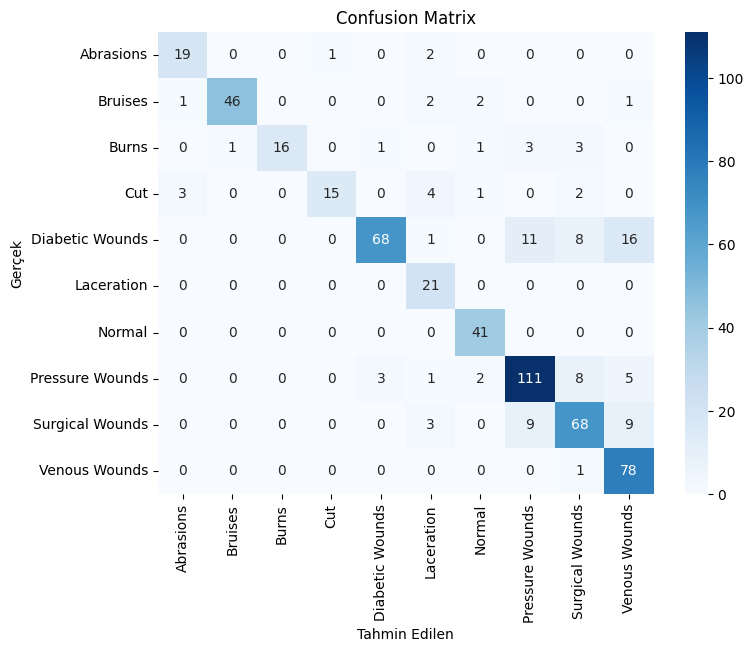

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
from sklearn.metrics import classification_report, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns 

#Cihaz ayarı
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

#Veri ve split
train_dir = "./merged/train"
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])
dataset = datasets.ImageFolder(train_dir, transform=transform)
classes = dataset.classes

#%80 eğitim, %20 validasyon
val_size = int(0.2 * len(dataset))
train_size = len(dataset) - val_size
train_ds, val_ds = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False)

#Model
model = models.resnet18(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, len(classes))
model = model.to(device)

#Kayıp ve optimizatör
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=3e-4, weight_decay=1e-4)

#Eğitim döngüsü
epochs = 5
best_val_loss = float('inf')

for epoch in range(1, epochs+1):
    model.train()
    running_loss = 0.0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    avg_train_loss = running_loss / len(train_loader)

    #Validation
    model.eval()
    val_loss = 0.0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            preds = outputs.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_val_loss = val_loss / len(val_loader)
    macro_f1 = f1_score(all_labels, all_preds, average='macro')
    report = classification_report(all_labels, all_preds, target_names=classes, digits=4)

    print(f"Epoch {epoch} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Macro F1: {macro_f1:.4f}")
    print(report)

    #En iyi modeli kaydet
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), "best_wound_resnet18.pt")

#Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.xlabel('Tahmin Edilen')
plt.ylabel('Gerçek')
plt.title('Confusion Matrix')
plt.show()


In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image

def generate_gradcam(model, image_tensor, target_class=None):
    model.eval()
    tensor = image_tensor.unsqueeze(0).to(device)
    features, gradients = [], []

    def forward_hook(module, inp, out):
        features.append(out)
    def backward_hook(module, grad_in, grad_out):
        gradients.append(grad_out[0])

    final_conv = model.layer4[1].conv2
    fh = final_conv.register_forward_hook(forward_hook)
    bh = final_conv.register_backward_hook(backward_hook)

    output = model(tensor)
    if target_class is None:
        target_class = output.argmax().item()
    model.zero_grad()
    output[0, target_class].backward()

    grad = gradients[0].mean(dim=[2,3], keepdim=True)
    fmap = features[0]
    cam = (fmap * grad).sum(dim=1).squeeze().detach().cpu().numpy()
    cam = np.maximum(cam, 0)
    cam = cam / cam.max()
    cam = cv2.resize(cam, (224,224))

    fh.remove(); bh.remove()
    return cam, target_class

def show_gradcam(image_path):
    img = Image.open(image_path).convert("RGB")
    tensor = transform(img)
    cam, pred = generate_gradcam(model, tensor)
    heatmap = cv2.applyColorMap(np.uint8(255*cam), cv2.COLORMAP_JET)
    img_np = np.array(img.resize((224,224)))
    overlay = cv2.addWeighted(img_np, 0.6, heatmap, 0.4, 0)
    plt.imshow(overlay); plt.title(f"Predicted: {class_names[pred]}"); plt.axis('off'); plt.show()
